In [1]:
# ============================================================
# CELL 1: IMPORTS + NOTEBOOK SETTINGS (TASK 3 - CLASSIFICATION)
# ============================================================

# ---- Core numeric/table libraries ----
import numpy as np                         # arrays, math ops, numeric utilities
import pandas as pd                        # DataFrame operations, reading CSV, cleaning

# ---- Plotting ----
import matplotlib.pyplot as plt            # matplotlib plots (ROC curves, etc.)

# ---- Warnings control ----
import warnings                            # control warnings to keep output clean
warnings.filterwarnings("ignore")          # hide non-critical warnings

# ---- Train/test split ----
from sklearn.model_selection import train_test_split  # split dataset into train/test sets

# ---- Preprocessing ----
from sklearn.preprocessing import StandardScaler       # scale numeric features (needed for LR/SVM)

# ---- Models (classification algorithms) ----
from sklearn.linear_model import LogisticRegression    # Logistic Regression classifier
from sklearn.tree import DecisionTreeClassifier        # Decision Tree classifier
from sklearn.ensemble import RandomForestClassifier    # Random Forest classifier
from sklearn.svm import SVC                            # Support Vector Machine classifier (EXTRA model)

# ---- Hyperparameter tuning ----
from sklearn.model_selection import GridSearchCV       # grid search cross-validation

# ---- Evaluation metrics ----
from sklearn.metrics import (
    accuracy_score,                  # overall correctness
    precision_score,                 # correctness of predicted positive class
    recall_score,                    # how many true positives we captured
    f1_score,                        # balance between precision and recall
    confusion_matrix,                # TP/TN/FP/FN table
    roc_auc_score,                   # area under ROC curve
    roc_curve                        # points for plotting ROC curve
)

# ---- Display settings (optional but helpful) ----
pd.set_option("display.max_columns", None)  # show all columns when printing DataFrames
pd.set_option("display.width", 160)         # make DataFrame printing wider


In [2]:
# ============================================================
# CELL 2: LOAD CLEANED DATASET FROM TASK 1
# ============================================================

# Path to the cleaned dataset created in Task 1
file_path = "cleaned_data.csv"             # this should exist in your notebook folder

# Read CSV into a DataFrame
df = pd.read_csv(file_path)                # df = game-level rows (each row is a player game)

# Print basic confirmation
print("✅ Loaded cleaned_data.csv successfully!")
print("Shape (rows, cols):", df.shape)

# Preview top rows (sanity check)
df.head()


✅ Loaded cleaned_data.csv successfully!
Shape (rows, cols): (16508, 28)


,Player,Tm,Opp,Res,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data,AST_TO_Ratio,ReboundActivity,PF_per_Min
0,Jayson Tatum,BOS,NYK,W,30.30,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,38.1,2024-10-22,5.0,4,0.033003
1,Anthony Davis,LAL,MIN,W,37.58,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,34.0,2024-10-22,2.0,16,0.026610
2,Derrick White,BOS,NYK,W,26.63,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,22.4,2024-10-22,4.0,3,0.037552
3,Jrue Holiday,BOS,NYK,W,30.52,7,9,0.778,4,6,0.667,0,0,0.000,2,2,4,4,1,0,0,2,18,19.5,2024-10-22,4.0,4,0.065531
4,Miles McBride,NYK,BOS,L,25.85,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,17.8,2024-10-22,1.0,0,0.038685


In [3]:
# ============================================================
# CELL 3: BUILD TARGET (Res) + DROP NON-USEFUL COLUMNS + FIX TYPES
# ============================================================

# -----------------------------
# 1) Confirm target column exists
# -----------------------------
if "Res" not in df.columns:
    raise ValueError("❌ 'Res' column not found in cleaned_data.csv. Task 3 requires it.")

# -----------------------------
# 2) Encode target: W -> 1, L -> 0
# -----------------------------
# (df["Res"] == "W") creates True/False, then .astype(int) converts True->1, False->0
df["Res_binary"] = (df["Res"] == "W").astype(int)

# Show target distribution (for imbalance check later)
print("Unique values in Res:", df["Res"].unique())
print("Target distribution (1=Win, 0=Loss):")
print(df["Res_binary"].value_counts())

# -----------------------------
# 3) Fix percentage columns if they are strings
# -----------------------------
# Some datasets store percentages like "45%" or as strings.
# We remove '%' and convert to numeric safely.
percent_cols = ["FG%", "3P%", "FT%"]

for col in percent_cols:
    if col in df.columns:
        # Convert to string to safely apply string replacements
        df[col] = df[col].astype(str)
        # Remove the '%' sign if present
        df[col] = df[col].str.replace("%", "", regex=False)
        # Convert to numeric; invalid parsing becomes NaN
        df[col] = pd.to_numeric(df[col], errors="coerce")

print("✅ Percentage columns converted (if they exist).")

# -----------------------------
# 4) Drop non-numeric / ID columns (not useful for baseline models)
# -----------------------------
# We remove player/team identifiers + original Res string.
# NOTE: In a more advanced version, you *could* encode these, but project doesn’t require it.
drop_cols = ["Player", "Tm", "Opp", "Date", "Matchup", "Res"]

# Keep only columns that actually exist (defensive coding)
drop_cols = [c for c in drop_cols if c in df.columns]

# Drop them
df_model = df.drop(columns=drop_cols).copy()

print("Dropped columns:", drop_cols)
print("Remaining shape:", df_model.shape)

# -----------------------------
# 5) Remove rows with missing target or missing features
# -----------------------------
# First: ensure target exists
if "Res_binary" not in df_model.columns:
    raise ValueError("❌ Res_binary missing after preprocessing. Something went wrong.")

# Drop rows with any NaNs (simple baseline)
before_rows = df_model.shape[0]
df_model = df_model.dropna()
after_rows = df_model.shape[0]

print(f"✅ Dropped rows with NaNs: {before_rows} → {after_rows}")

# -----------------------------
# 6) (Optional) Remove features that can be considered "near-leakage"
# -----------------------------
# +/- is strongly tied to winning margin while player is on the court.
# Some instructors consider it too close to the answer.
# If your dataset includes "+/-", it can make the task too easy.
if "+/-" in df_model.columns:
    df_model = df_model.drop(columns=["+/-"])
    print("⚠️ Removed '+/-' to avoid near-leakage (optional but recommended).")

# Final preview
df_model.head()


Unique values in Res: ['W' 'L']
Target distribution (1=Win, 0=Loss):
Res_binary
0    8261
1    8247
Name: count, dtype: int64
✅ Percentage columns converted (if they exist).
Dropped columns: ['Player', 'Tm', 'Opp', 'Res']
Remaining shape: (16508, 25)
✅ Dropped rows with NaNs: 16508 → 16508


,MP,FG,FGA,FG%,3P,3PA,3P%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,GmSc,Data,AST_TO_Ratio,ReboundActivity,PF_per_Min,Res_binary
0,30.30,14,18,0.778,8,11,0.727,1,2,0.500,0,4,4,10,1,1,1,1,37,38.1,2024-10-22,5.0,4,0.033003,1
1,37.58,11,23,0.478,1,3,0.333,13,15,0.867,3,13,16,4,1,3,1,1,36,34.0,2024-10-22,2.0,16,0.026610,1
2,26.63,8,13,0.615,6,10,0.600,2,2,1.000,0,3,3,4,1,0,0,1,24,22.4,2024-10-22,4.0,3,0.037552,1
3,30.52,7,9,0.778,4,6,0.667,0,0,0.000,2,2,4,4,1,0,0,2,18,19.5,2024-10-22,4.0,4,0.065531,1
4,25.85,8,10,0.800,4,5,0.800,2,3,0.667,0,0,0,2,0,0,1,1,22,17.8,2024-10-22,1.0,0,0.038685,0


In [4]:
# ============================================================
# CELL 4 (EDITED): BUILD X/y + CHECK IMBALANCE + TRAIN/TEST SPLIT + SCALING
# ============================================================

# -----------------------------
# 1) Separate target and features
# -----------------------------
y = df_model["Res_binary"].copy()                 # target vector (0/1)
X = df_model.drop(columns=["Res_binary"]).copy()  # feature matrix (may still include non-numeric by mistake)

# -----------------------------
# 2) IMPORTANT FIX: keep ONLY numeric features
# -----------------------------
# This prevents errors like: "could not convert string to float: '2025-01-08'"
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()
if len(non_numeric_cols) > 0:
    print("⚠️ Dropping non-numeric columns from X (to avoid scaling errors):", non_numeric_cols)
    X = X.select_dtypes(include=[np.number])

print("X shape (numeric only):", X.shape)
print("y shape:", y.shape)

# -----------------------------
# 3) Check class imbalance (W/L ratio)
# -----------------------------
win_ratio = y.mean()
print(f"Win ratio (1=Win): {win_ratio:.3f}")

if win_ratio < 0.30 or win_ratio > 0.70:
    print("⚠️ Class imbalance detected. We'll use class_weight='balanced' where possible.")
else:
    print("✅ Class balance looks acceptable.")

# -----------------------------
# 4) Train/Test split with stratify
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes: ", X_test.shape, y_test.shape)

# -----------------------------
# 5) Scaling for LR and SVM ONLY
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit on TRAIN only
X_test_scaled  = scaler.transform(X_test)       # transform TEST using train stats

print("✅ Scaling complete (for Logistic Regression & SVM).")


⚠️ Dropping non-numeric columns from X (to avoid scaling errors): ['Data']
X shape (numeric only): (16508, 23)
y shape: (16508,)
Win ratio (1=Win): 0.500
✅ Class balance looks acceptable.
Train shapes: (13206, 23) (13206,)
Test shapes:  (3302, 23) (3302,)
✅ Scaling complete (for Logistic Regression & SVM).


In [5]:
# ============================================================
# CELL 5: HELPER FUNCTIONS FOR EVALUATION + ROC PLOTTING
# ============================================================

def evaluate_classifier(y_true, y_pred, y_proba=None, model_name="Model"):
    """
    Evaluate a classifier using project-required metrics:
    Accuracy, Precision, Recall, F1, Confusion Matrix, ROC-AUC (if probabilities provided).
    """
    # ---- Core metrics ----
    acc = accuracy_score(y_true, y_pred)                      # overall accuracy
    prec = precision_score(y_true, y_pred, zero_division=0)   # precision for class=1
    rec = recall_score(y_true, y_pred, zero_division=0)       # recall for class=1
    f1 = f1_score(y_true, y_pred, zero_division=0)            # f1 score for class=1

    # ---- Confusion Matrix ----
    cm = confusion_matrix(y_true, y_pred)                     # [[TN, FP],[FN, TP]]

    # ---- ROC-AUC ----
    # Only compute ROC-AUC if we have probabilities for class 1
    auc = None
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)

    # ---- Print results ----
    print(f"\n{model_name} Results")
    print("-" * 60)
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-Score : {f1:.3f}")

    if auc is not None:
        print(f"ROC-AUC  : {auc:.3f}")

    print("\nConfusion Matrix [[TN, FP],[FN, TP]]:")
    print(cm)

    # Return metrics so we can build a comparison table later
    return {"Model": model_name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC_AUC": auc}


def plot_roc_curve(y_true, y_proba, label="Model"):
    """
    Plot ROC curve given true labels and predicted probabilities for class=1.
    """
    fpr, tpr, _ = roc_curve(y_true, y_proba)   # compute ROC points
    auc_val = roc_auc_score(y_true, y_proba)   # compute AUC score
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc_val:.3f})")


In [6]:
# ============================================================
# CELL 6: MODEL 1 — LOGISTIC REGRESSION (REQUIRED)
# ============================================================

# Create Logistic Regression model
# class_weight='balanced' helps if W/L classes are imbalanced
log_reg = LogisticRegression(
    max_iter=2000,           # increase iterations so solver converges
    solver="lbfgs",          # common solver for logistic regression
    class_weight="balanced"  # handle imbalance automatically
)

# Train model on SCALED training data
log_reg.fit(X_train_scaled, y_train)

# Predict class labels on test data
y_pred_lr = log_reg.predict(X_test_scaled)

# Predict probabilities for ROC-AUC (probability of class 1 = Win)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluate
lr_metrics = evaluate_classifier(y_test, y_pred_lr, y_proba_lr, model_name="Logistic Regression")



Logistic Regression Results
------------------------------------------------------------
Accuracy : 0.571
Precision: 0.570
Recall   : 0.576
F1-Score : 0.573
ROC-AUC  : 0.611

Confusion Matrix [[TN, FP],[FN, TP]]:
[[935 717]
 [699 951]]


In [7]:
# ============================================================
# CELL 7: MODEL 2 — DECISION TREE (REQUIRED)
# ============================================================

# Decision Trees do NOT require scaling (they split by thresholds)
dt_clf = DecisionTreeClassifier(
    random_state=42,          # reproducibility
    max_depth=None,           # allow full depth (we will discuss overfitting risk in report)
    class_weight="balanced"   # helps if imbalance exists
)

# Train on UNSCALED training data
dt_clf.fit(X_train, y_train)

# Predict labels on test set
y_pred_dt = dt_clf.predict(X_test)

# Predict probabilities for ROC-AUC
y_proba_dt = dt_clf.predict_proba(X_test)[:, 1]

# Evaluate
dt_metrics = evaluate_classifier(y_test, y_pred_dt, y_proba_dt, model_name="Decision Tree")



Decision Tree Results
------------------------------------------------------------
Accuracy : 0.529
Precision: 0.530
Recall   : 0.519
F1-Score : 0.524
ROC-AUC  : 0.530

Confusion Matrix [[TN, FP],[FN, TP]]:
[[891 761]
 [793 857]]


In [8]:
# ============================================================
# CELL 8: MODEL 3 — RANDOM FOREST (REQUIRED)
# ============================================================

# Random Forest = ensemble of decision trees
rf_clf = RandomForestClassifier(
    n_estimators=300,         # number of trees
    random_state=42,          # reproducibility
    n_jobs=-1,                # use all CPU cores
    class_weight="balanced"   # handle imbalance
)

# Train on UNSCALED training data
rf_clf.fit(X_train, y_train)

# Predict labels
y_pred_rf = rf_clf.predict(X_test)

# Predict probabilities for ROC-AUC
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

# Evaluate
rf_metrics = evaluate_classifier(y_test, y_pred_rf, y_proba_rf, model_name="Random Forest")



Random Forest Results
------------------------------------------------------------
Accuracy : 0.573
Precision: 0.577
Recall   : 0.544
F1-Score : 0.560
ROC-AUC  : 0.587

Confusion Matrix [[TN, FP],[FN, TP]]:
[[994 658]
 [752 898]]


In [9]:
# ============================================================
# CELL 9: MODEL 4 — SVM (EXTRA )
# ============================================================
# NOTE (IMPORTANT FOR REPORT):
# The project requires at least 3 models.
# We include SVM as an EXTRA model (bonus) to strengthen comparison.

# SVM benefits heavily from scaling → use X_train_scaled / X_test_scaled
svm_clf = SVC(
    kernel="rbf",              # non-linear boundary
    C=1.0,                     # regularization strength
    gamma="scale",             # safe default
    probability=True,          # needed for ROC-AUC probabilities
    class_weight="balanced",   # handle imbalance
    random_state=42
)

# Train on scaled data
svm_clf.fit(X_train_scaled, y_train)

# Predict labels
y_pred_svm = svm_clf.predict(X_test_scaled)

# Predict probabilities for ROC-AUC
y_proba_svm = svm_clf.predict_proba(X_test_scaled)[:, 1]

# Evaluate
svm_metrics = evaluate_classifier(y_test, y_pred_svm, y_proba_svm, model_name="SVM (RBF) [EXTRA]")



SVM (RBF) [EXTRA] Results
------------------------------------------------------------
Accuracy : 0.582
Precision: 0.587
Recall   : 0.548
F1-Score : 0.567
ROC-AUC  : 0.605

Confusion Matrix [[TN, FP],[FN, TP]]:
[[1017  635]
 [ 746  904]]


In [10]:
# ============================================================
# CELL 10: HYPERPARAMETER TUNING (REQUIRED) — GRID SEARCH ON RF
# ============================================================
# Requirement: Tune at least ONE model using Grid Search or Random Search.
# We'll tune Random Forest using ROC-AUC as the scoring metric.

# Define parameter grid (keep small to avoid long runtime)
param_grid_rf = {
    "n_estimators": [200, 400],          # number of trees
    "max_depth": [None, 10, 20],         # tree depth
    "min_samples_split": [2, 5],         # min samples to split
    "min_samples_leaf": [1, 2]           # min samples in leaf
}

# Base RF model for search
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Grid search with cross-validation
grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring="roc_auc",    # optimize for ROC-AUC
    cv=3,                 # 3-fold CV (fast + acceptable)
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV for Random Forest...")
grid_rf.fit(X_train, y_train)

print("\n✅ Best RF parameters:")
print(grid_rf.best_params_)
print(f"✅ Best CV ROC-AUC: {grid_rf.best_score_:.3f}")

# Use the best model found
best_rf = grid_rf.best_estimator_

# Predict using best RF
y_pred_best_rf = best_rf.predict(X_test)
y_proba_best_rf = best_rf.predict_proba(X_test)[:, 1]

# Evaluate best RF
best_rf_metrics = evaluate_classifier(y_test, y_pred_best_rf, y_proba_best_rf, model_name="Random Forest (Tuned)")


Running GridSearchCV for Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits

✅ Best RF parameters:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 400}
✅ Best CV ROC-AUC: 0.612

Random Forest (Tuned) Results
------------------------------------------------------------
Accuracy : 0.580
Precision: 0.587
Recall   : 0.536
F1-Score : 0.560
ROC-AUC  : 0.608

Confusion Matrix [[TN, FP],[FN, TP]]:
[[1030  622]
 [ 766  884]]


📊 Final Model Comparison (sorted by ROC-AUC):


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.571169,0.570144,0.576364,0.573237,0.611475
4,Random Forest (Tuned),0.579649,0.586985,0.535758,0.560203,0.608237
3,SVM (RBF) [EXTRA],0.581769,0.587394,0.547879,0.566949,0.604557
2,Random Forest,0.572986,0.577121,0.544242,0.560200,0.587018
1,Decision Tree,0.529376,0.529666,0.519394,0.524480,0.529950


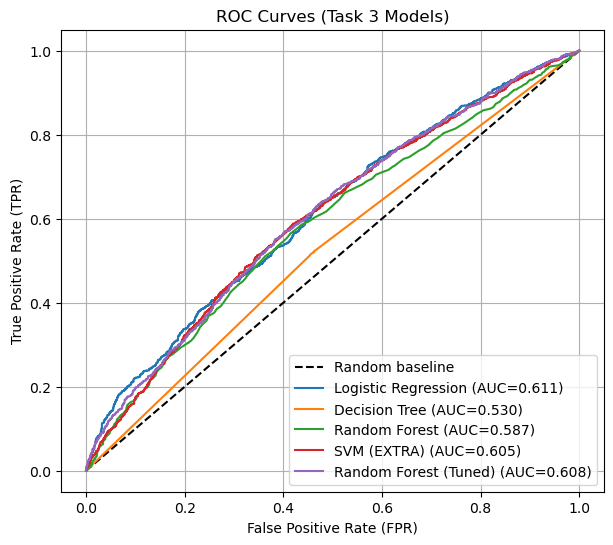

In [11]:
# ============================================================
# CELL 11: FINAL COMPARISON TABLE + ROC CURVES (ALL MODELS)
# ============================================================

# Collect metrics into one list
all_metrics = [lr_metrics, dt_metrics, rf_metrics, svm_metrics, best_rf_metrics]

# Convert to DataFrame
results_df = pd.DataFrame(all_metrics)

# Sort by ROC_AUC (best first). If ROC_AUC has None, it will appear last.
results_sorted = results_df.sort_values(by="ROC_AUC", ascending=False)

print("📊 Final Model Comparison (sorted by ROC-AUC):")
display(results_sorted)

# -----------------------------
# Plot ROC curves together
# -----------------------------
plt.figure(figsize=(7, 6))

# Baseline diagonal (random classifier)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")

# Plot ROC for each model (only if proba exists)
plot_roc_curve(y_test, y_proba_lr, label="Logistic Regression")
plot_roc_curve(y_test, y_proba_dt, label="Decision Tree")
plot_roc_curve(y_test, y_proba_rf, label="Random Forest")
plot_roc_curve(y_test, y_proba_svm, label="SVM (EXTRA)")
plot_roc_curve(y_test, y_proba_best_rf, label="Random Forest (Tuned)")

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curves (Task 3 Models)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
